In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from scipy import stats

In [2]:
rf_data = pd.read_csv("RF_prediction.csv")
rf_data['observationTime'] = pd.to_datetime(rf_data['observationTime'])
rf_data.head()

,observationTime,rf_prediction,actual,ECMWF
0,2024-02-02,4.749,0.5,6.074154
1,2024-02-03,1.195,3.4,2.074088
2,2024-02-04,3.381,6.5,3.847310
3,2024-02-05,3.576,6.2,4.799108
4,2024-02-06,8.456,2.8,8.335825


In [3]:
xgb_data = pd.read_csv("xgboost_pred.csv")
xgb_data['observationTime'] = pd.to_datetime(xgb_data['observationTime'])
xgb_data.head()

,observationTime,actual,xgb_predicted
0,2018-07-12,0.3,1.238406
1,2018-07-13,24.0,22.250040
2,2018-07-14,13.3,15.661434
3,2018-07-15,11.1,10.932304
4,2018-07-16,4.8,2.656915


In [4]:
data_full = rf_data.merge(xgb_data[['observationTime', 'xgb_predicted']], on='observationTime', how='left')
data_full.head()

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted
0,2024-02-02,4.749,0.5,6.074154,5.147978
1,2024-02-03,1.195,3.4,2.074088,1.390713
2,2024-02-04,3.381,6.5,3.847310,3.099278
3,2024-02-05,3.576,6.2,4.799108,4.224149
4,2024-02-06,8.456,2.8,8.335825,7.595597


In [5]:
data_full.shape

(730, 5)

In [6]:
data_full.head()

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted
0,2024-02-02,4.749,0.5,6.074154,5.147978
1,2024-02-03,1.195,3.4,2.074088,1.390713
2,2024-02-04,3.381,6.5,3.847310,3.099278
3,2024-02-05,3.576,6.2,4.799108,4.224149
4,2024-02-06,8.456,2.8,8.335825,7.595597


In [7]:
data_full.to_csv('All_predictions_rf_xgb.csv', index=False)

In [8]:
split_idx = int(len(data_full) * 0.8)

train = data_full.iloc[:split_idx].copy()
test  = data_full.iloc[split_idx:].copy()

target = 'actual'
drop_cols = ['observationTime', target]

X_train = train.drop(columns=drop_cols)
y_train = train[target]
X_test = test.drop(columns=drop_cols)
y_test = test[target]

In [9]:
X_train.head()

,rf_prediction,ECMWF,xgb_predicted
0,4.749,6.074154,5.147978
1,1.195,2.074088,1.390713
2,3.381,3.847310,3.099278
3,3.576,4.799108,4.224149
4,8.456,8.335825,7.595597


In [10]:
pradzia = train['observationTime'].min()
pabaiga = train['observationTime'].max()

print(f"Mokymo aibė nuo {pradzia} iki {pabaiga} (dydis: {train.shape})")

Mokymo aibė nuo 2024-02-02 00:00:00 iki 2025-09-07 00:00:00 (dydis: (584, 5))


In [11]:
pradzia = test['observationTime'].min()
pabaiga = test['observationTime'].max()

print(f"Testavimo aibė nuo {pradzia} iki {pabaiga} (dydis: {test.shape})")

Testavimo aibė nuo 2025-09-08 00:00:00 iki 2026-01-31 00:00:00 (dydis: (146, 5))


In [12]:
dt_mdl = DecisionTreeRegressor(random_state=123)
dt_mdl.fit(X_train, y_train)
new_pred_dt_mdl = dt_mdl.predict(X_test)

In [13]:
rf_mdl = RandomForestRegressor(random_state=123)
rf_mdl.fit(X_train, y_train)
new_pred_rf_mdl = rf_mdl.predict(X_test)

In [14]:
def metrics_fun(y_val_true, rf_pred_val):
    print(f'R^2:  {r2_score(y_val_true, rf_pred_val)}')
    print(f'MAE:  {mean_absolute_error(y_val_true, rf_pred_val)}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_val_true, rf_pred_val))}')
    # print(f'MAPE: {mean_absolute_percentage_error(y_val_true, rf_pred_val)}')
    corr, p_value = stats.spearmanr(y_val_true, rf_pred_val)
    print(f"r_s:  {corr}")

Globalus

In [15]:
metrics_fun(y_test, X_test['ECMWF'])

R^2:  0.6465257315214816
MAE:  1.0482922759613267
RMSE: 2.2721097766469334
r_s:  0.7713476720606083


DecisionTreeRegressor

In [16]:
metrics_fun(y_test, new_pred_dt_mdl)

R^2:  0.5324747294143201
MAE:  1.322867767113788
RMSE: 2.6130814886078637
r_s:  0.6150674351946136


RandomForestRegressor

In [17]:
metrics_fun(y_test, new_pred_rf_mdl)

R^2:  0.6662094416010746
MAE:  0.9716417397165279
RMSE: 2.2079408380817624
r_s:  0.7622790573727791


In [26]:
ensemble_series = pd.Series(new_pred_rf_mdl, index=test.index, name='ensemble_rf_pred')
data_full['ensemble_rf_pred'] = ensemble_series
data_full.to_csv('All_with_ensemble_rf.csv', index=False)

In [18]:
rf_default_importances = rf_mdl.feature_importances_
rf_default_importances

array([0.3364606 , 0.44361179, 0.21992761])

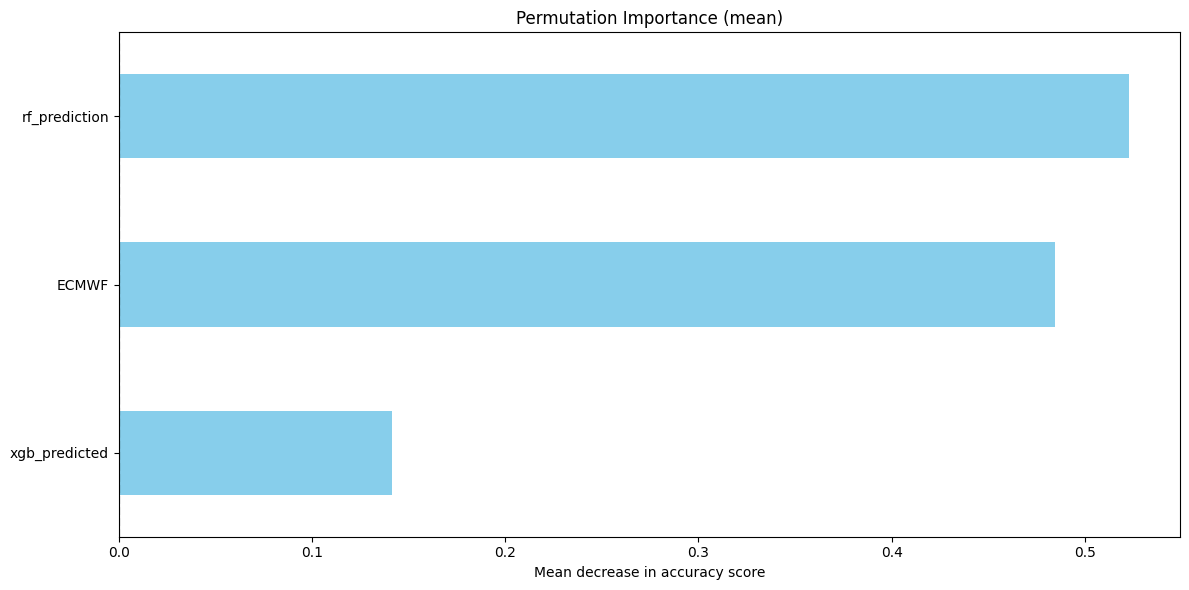

In [19]:
result = permutation_importance(rf_mdl, X_test, y_test, n_repeats=5, random_state=123)
sorted_importances_idx = result.importances_mean.argsort()

importances_df = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_test.columns[sorted_importances_idx])

forest_importances = pd.Series(result.importances_mean, index=X_test.columns)
forest_importances = forest_importances[forest_importances > 0]
forest_importances = forest_importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
forest_importances.plot.barh(ax=ax, color='skyblue')
ax.set_title("Permutation Importance (mean)")
ax.set_xlabel("Mean decrease in accuracy score")
ax.axvline(x=0, color="k", linestyle="--")

fig.tight_layout()
plt.show()

In [20]:
# from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# param_grid = {
#     'n_estimators': [50, 100, 150, 200],
#     'max_depth': [None, 4, 6, 8, 10],
#     'max_features': [0.4, 0.7, 0.9, 0.95, 1.0],
#     'min_samples_leaf': [1, 2, 3, 4, 5]
# }

# tscv = TimeSeriesSplit(n_splits=5)
# random_search = GridSearchCV(estimator=RandomForestRegressor(random_state=123), param_grid=param_grid,
#                              cv=tscv, scoring='neg_root_mean_squared_error')
# random_search.fit(X_train, y_train)
# best_model = random_search.best_estimator_
# print(f"Geriausi parametrai: {random_search.best_params_}")

In [21]:
# new_pred = best_model.predict(X_test)
# metrics_fun(y_test, new_pred)